In [1]:
try:
    %pip install --user "oracledb" --no-warn-script-location
except Exception as e:
    print("Install error")
    raise

Note: you may need to restart the kernel to use updated packages.


In [2]:
import oracledb

dsn = oracledb.makedsn("localhost", 1522, service_name="stu")

connection = oracledb.connect(
    user="ora_rish05",
    password="a71497275",
    dsn=dsn
)

print("Connected successfully")

connection.close()

Connected successfully


In [6]:
import oracledb

dsn = oracledb.makedsn("localhost", 1522, service_name="stu")

connection = oracledb.connect(
    user="ora_rish05",
    password="a71497275",
    dsn=dsn
)

cursor = connection.cursor()

cursor.execute("""
CREATE TABLE weekly_global (
    week DATE,
    category VARCHAR2(50),
    weekly_rank NUMBER,
    show_title VARCHAR2(300),
    season_title VARCHAR2(300),
    weekly_hours_viewed NUMBER,
    weekly_views NUMBER
)
""")

connection.commit()

print("Table created")

cursor.close()
connection.close()

DatabaseError: ORA-00955: name is already used by an existing object
Help: https://docs.oracle.com/error-help/db/ora-00955/

In [7]:
import os
os.listdir()

['most-popular.csv',
 'Tutorial 0',
 'all-weeks-global.csv',
 'mongo-in-class-exercise.ipynb',
 '.cache',
 '.ssh',
 '.ipynb_checkpoints',
 'CPSCData_Cleaning_Phase3.ipynb',
 'Untitled Folder',
 'archive (1).zip',
 '.ipython',
 '.npm',
 'all-weeks-countries.csv',
 '.config',
 'netflix_titles.csv',
 'Untitled Folder 1',
 '.local',
 '.jupyter',
 '.bash_history',
 'R',
 'cleaned_weekly_global_q3.csv']

In [8]:
import pandas as pd

weekly = pd.read_csv("all-weeks-global.csv", encoding="latin1")

weekly.head()


,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10,is_staggered_launch,episode_launch_details
0,2023-12-17,Films (English),1,Leave the World Behind,NaN,106200000,2.3667,44900000.0,2,False,NaN
1,2023-12-17,Films (English),2,Chicken Run: Dawn of the Nugget,NaN,20300000,1.7000,11900000.0,1,False,NaN
2,2023-12-17,Films (English),3,Leo,NaN,16800000,1.7833,9400000.0,4,False,NaN
3,2023-12-17,Films (English),4,Family Switch,NaN,16600000,1.7667,9400000.0,3,False,NaN
4,2023-12-17,Films (English),5,The Super Mario Bros. Movie,NaN,13700000,1.5333,8900000.0,3,False,NaN


In [9]:
weekly = weekly[
    [
        "week",
        "category",
        "weekly_rank",
        "show_title",
        "season_title",
        "weekly_hours_viewed",
        "weekly_views"
    ]
]

weekly.head()

,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,weekly_views
0,2023-12-17,Films (English),1,Leave the World Behind,NaN,106200000,44900000.0
1,2023-12-17,Films (English),2,Chicken Run: Dawn of the Nugget,NaN,20300000,11900000.0
2,2023-12-17,Films (English),3,Leo,NaN,16800000,9400000.0
3,2023-12-17,Films (English),4,Family Switch,NaN,16600000,9400000.0
4,2023-12-17,Films (English),5,The Super Mario Bros. Movie,NaN,13700000,8900000.0


In [10]:
weekly = weekly.dropna(subset=["show_title"])
weekly.shape

(5160, 7)

In [11]:
import re

# normalize titles
def normalize_title(text):
    if pd.isna(text):
        return None
    text = str(text).lower().strip()
    text = re.sub(r"[^\w\s]", "", text)   # remove punctuation
    text = re.sub(r"\s+", " ", text)      # collapse whitespace
    return text

# clean titles
weekly["show_title"] = weekly["show_title"].apply(normalize_title)

# clean category
weekly["category"] = weekly["category"].astype(str).str.lower().str.strip()

# convert week to date
weekly["week"] = pd.to_datetime(weekly["week"], errors="coerce")

# remove bad dates
weekly = weekly.dropna(subset=["week"])

# remove duplicates
weekly = weekly.drop_duplicates()

# save cleaned dataset
weekly.to_csv("cleaned_weekly_global_q3.csv", index=False)

print("Cleaning complete")
print("Rows:", weekly.shape)


Cleaning complete
Rows: (5160, 7)


In [12]:
import oracledb
import pandas as pd
import numpy as np

# load cleaned dataset
df = pd.read_csv("cleaned_weekly_global_q3.csv")

# fix types
df["week"] = pd.to_datetime(df["week"]).dt.strftime("%Y-%m-%d")

df["weekly_rank"] = pd.to_numeric(df["weekly_rank"], errors="coerce")
df["weekly_hours_viewed"] = pd.to_numeric(df["weekly_hours_viewed"], errors="coerce")
df["weekly_views"] = pd.to_numeric(df["weekly_views"], errors="coerce")

# convert NaN → None (Oracle requires None)
df = df.replace({np.nan: None})

# connect to Oracle
dsn = oracledb.makedsn("localhost", 1522, service_name="stu")

connection = oracledb.connect(
    user="ora_rish05",
    password="a71497275",
    dsn=dsn
)

cursor = connection.cursor()

sql = """
INSERT INTO weekly_global (
    week,
    category,
    weekly_rank,
    show_title,
    season_title,
    weekly_hours_viewed,
    weekly_views
)
VALUES (
    TO_DATE(:1,'YYYY-MM-DD'),
    :2,
    :3,
    :4,
    :5,
    :6,
    :7
)
"""

data = list(df.itertuples(index=False, name=None))

cursor.executemany(sql, data)

connection.commit()

print("Rows inserted:", len(data))

cursor.close()
connection.close()

Rows inserted: 5160


In [14]:
import pandas as pd
import oracledb
import numpy as np
import re

# load dataset
popular = pd.read_csv("most-popular.csv", encoding="latin1")

# keep only needed columns
popular = popular[
    [
        "category",
        "show_title",
        "season_title",
        "hours_viewed_first_91_days",
        "views_first_91_days"
    ]
]

# normalize titles
def normalize_title(text):
    if pd.isna(text):
        return None
    text = str(text).lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

popular["show_title"] = popular["show_title"].apply(normalize_title)
popular["category"] = popular["category"].astype(str).str.lower().str.strip()

# convert numbers
popular["hours_viewed_first_91_days"] = pd.to_numeric(popular["hours_viewed_first_91_days"], errors="coerce")
popular["views_first_91_days"] = pd.to_numeric(popular["views_first_91_days"], errors="coerce")

# replace NaN with None
popular = popular.replace({np.nan: None})

# connect to Oracle
dsn = oracledb.makedsn("localhost", 1522, service_name="stu")

connection = oracledb.connect(
    user="ora_rish05",
    password="a71497275",
    dsn=dsn
)

cursor = connection.cursor()

sql = """
INSERT INTO most_popular (
    category,
    show_title,
    season_title,
    hours_viewed_first_91_days,
    views_first_91_days
)
VALUES (
    :1,
    :2,
    :3,
    :4,
    :5
)
"""

data = list(popular.itertuples(index=False, name=None))

cursor.executemany(sql, data)

connection.commit()

print("Rows inserted:", len(data))

cursor.close()
connection.close()

Rows inserted: 40


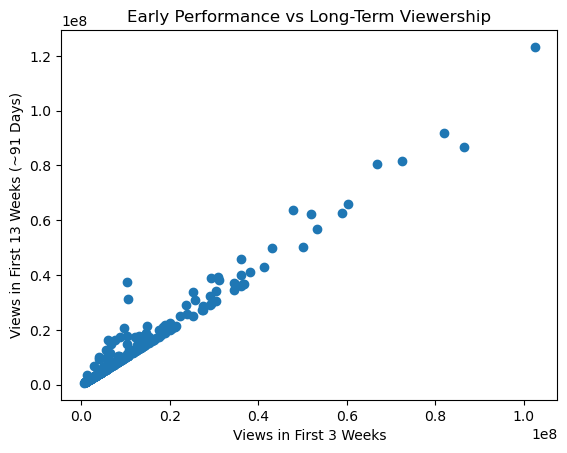

In [20]:
import matplotlib.pyplot as plt

plt.scatter(df["VIEWS_FIRST3WEEKS"], df["VIEWS_FIRST13WEEKS"])

plt.xlabel("Views in First 3 Weeks")
plt.ylabel("Views in First 13 Weeks (~91 Days)")
plt.title("Early Performance vs Long-Term Viewership")

plt.show()